In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch

In [3]:
device = torch.device('cpu') if not torch.accelerator.is_available() else torch.accelerator.current_accelerator()
print(device)

mps


# Hyperparameters

In [4]:
batch_size = 128
resize = (32, 32)
num_epochs = 10
lr = 0.001

# Load dataset

In [5]:
from utils.data import CIFAR10, FashionMNIST
from utils.train import train_model, val_stats

def get_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=lr)

def fit(model, num_epochs=num_epochs):
    dataset = CIFAR10(batch_size=batch_size, resize=resize, device=device)
    train_dl, val_dl = dataset.get_dataloaders()
    optimizer = get_optimizer(model)
    return train_model(model, train_dl, val_dl, optimizer, num_epochs)

# Create model

We'll be implementing the GoogLeNet (multi-branch network) architecture here.

What makes the multi-branch network different is that convolutions of multiple sizes are used at the same layer, then concatenated together. This is called an "inception" block. The main hyperparameter in each "inception" block is the number of channels used.

In [6]:
from torch import nn
import torch.nn.functional as F
from utils.models import Module

### BatchNorm from scratch

In [7]:
def batch_norm(X, moving_mean, moving_var, gamma, beta, eps, momentum):
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            mean = torch.mean(X, dim=0)
            var = torch.var(X, dim=0)
        else:
            mean = torch.mean(X, dim=(0, 2, 3), keepdim=True)
            var = torch.var(X, dim=(0, 2, 3), keepdim=True)
        
        X_hat = (X - mean) / torch.sqrt(var + eps)
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
        
    Y = gamma * X_hat + beta
    return Y, moving_mean.data, moving_var.data

In [8]:
class BatchNorm(nn.Module):
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        elif num_dims == 4:
            shape = (1, num_features, 1, 1)
        else:
            raise ValueError("Invalid number of dimensions")
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))

        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)
    
    def forward(self, X):
        if self.moving_mean != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.moving_mean, self.moving_var,
            self.gamma, self.beta, eps=1e-5, momentum=0.1)
        return Y

### Implement model

In [9]:
class BNLeNetScratch(Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), 
            BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), 
            BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), 
            nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), 
            nn.Sigmoid(),
            nn.LazyLinear(num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [10]:
model_scratch = BNLeNetScratch().to(device)
X = torch.randn(batch_size, 3, *resize).to(device)

In [11]:
with torch.no_grad():
    print(model_scratch(X).shape)

print(model_scratch)

torch.Size([128, 10])
BNLeNetScratch(
  (net): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm()
    (2): Sigmoid()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm()
    (6): Sigmoid()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=400, out_features=120, bias=True)
    (10): BatchNorm()
    (11): Sigmoid()
    (12): Linear(in_features=120, out_features=84, bias=True)
    (13): BatchNorm()
    (14): Sigmoid()
    (15): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [12]:
num_params = sum(p.numel() for p in model_scratch.parameters())
print(num_params)
print(f"Parameter memory: {num_params * 4 / 1e6:.0f} MB")

62458
Parameter memory: 0 MB


# Train model from scratch

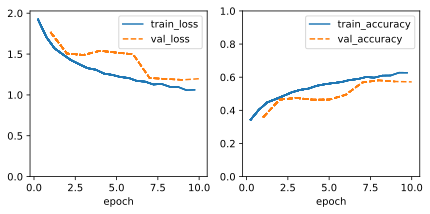

In [13]:
fit(model_scratch);

In [14]:
_, val_dl = CIFAR10(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model_scratch, val_dl, device=device)

In [15]:
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}%")

Validation loss: 1.20, accuracy: 0.57%


# How much memory usage during training?

In [16]:
print(f"Max memory allocated: {torch.cuda.max_memory_allocated()/1e9:.3f} GB")

Max memory allocated: 0.000 GB


# Train model using Torch BatchNorm

In [17]:
class BNLeNet(Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), 
            nn.BatchNorm2d(6),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), 
            nn.BatchNorm2d(16),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            nn.BatchNorm1d(120), 
            nn.Sigmoid(), nn.LazyLinear(84),
            nn.BatchNorm1d(84), 
            nn.Sigmoid(),
            nn.LazyLinear(num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [18]:
model_concise = BNLeNet().to(device)
X = torch.randn(batch_size, 3, *resize).to(device)

with torch.no_grad():
    print(model_concise(X).shape)

print(model_concise)

torch.Size([128, 10])
BNLeNet(
  (net): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Sigmoid()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Sigmoid()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=400, out_features=120, bias=True)
    (10): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Sigmoid()
    (12): Linear(in_features=120, out_features=84, bias=True)
    (13): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): Sigmoid()
    (15): Linear(in_features=84, out_features=10, bias=True)
  )
)


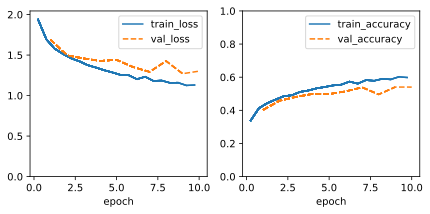

In [19]:
fit(model_concise);

In [20]:
_, val_dl = CIFAR10(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model_scratch, val_dl, device=device)

In [21]:
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}%")

Validation loss: 1.20, accuracy: 0.57%
